# Modeling and calibration of aggregate aviation demand for climate mitigation scenarios

This document has been published for reproducing the application presented in the World Conference on Transport Research - WCTR 2026 Toulouse 6-10 July 2026.

The goal of the paper is to review and compare different formulations for modeling long-term aviation demand based on prices and socioeconomic drivers.
The model calibration was performed outside of AeroMAPS, but the calibrated models were then implemented in AeroMAPS and used for simulating the evolution of aviation demand and its related impacts (emissions, climate, costs) under different scenarios.

Each scenario uses population, GDP, and carbon price based on an SSP2 mitigation scenario from the Scenario Database of the 6th IPCC's Assessment Report, with varying target radiative forcing levels by the end of the century. The forcing levels of 1.9 and 2.6 $W/m^2$ being in the range of respect of the Paris Agreement.


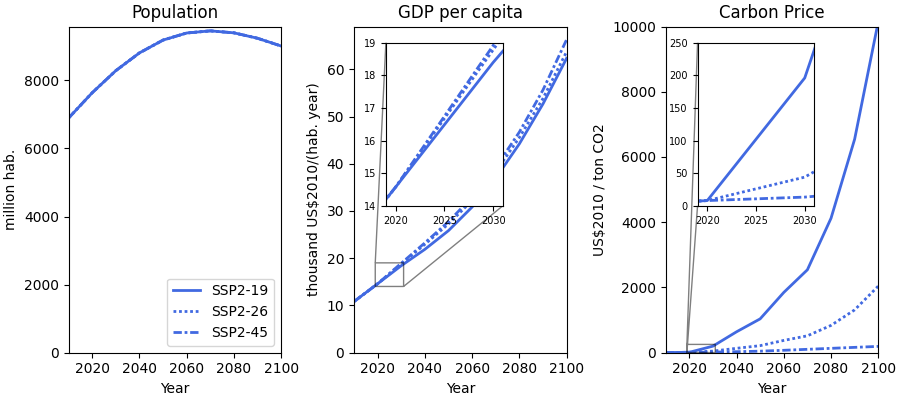

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from aeromaps import create_process, assemble_processes
from get_data import get_ar6_input_data

ar6_data, ar6_years = get_ar6_input_data(start_year=2010, end_year=2100, plot_data=True)

In the present context, it is also worthwile to analyse the impact of fluctuations in the jet fuel price based on its historical variation. Especially, since the ongoing war on Iran has raised prices near the max historical value, and the future evolution of the conflict is uncertain.


Kerosene price in 2019: 0.01265556850664434 €/MJ
Minimum historical kerosene price: 0.0034686630020871927 €/MJ
Maximum historical kerosene price: 0.026173251312836567 €/MJ


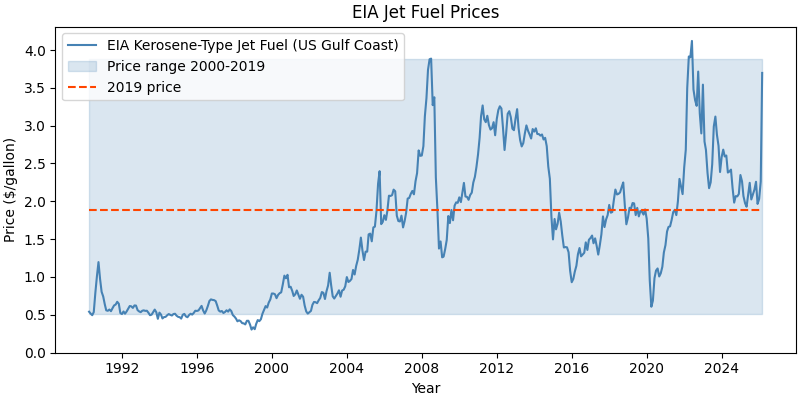

In [2]:
eia_prices = pd.read_csv('./data/eia_jet_fuel_prices.csv', parse_dates=['observation_date'])

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
ax.plot(
    eia_prices['observation_date'],
    eia_prices['MJFUELUSGULF'],
    color='steelblue',
    linewidth=1.5,
    label='EIA Kerosene-Type Jet Fuel (US Gulf Coast)'
)
ax.set_title('EIA Jet Fuel Prices')
ax.set_xlabel('Year')
ax.set_ylabel('Price ($/gallon)')
ax.set_ylim(bottom=0)

kerosene_price_per_gal_2019 = 1.879
eia_prices_2000_2019 = eia_prices[
    (eia_prices['observation_date'].dt.year >= 2000) &
    (eia_prices['observation_date'].dt.year <= 2019)
]
kerosene_price_per_gal_min = eia_prices_2000_2019["MJFUELUSGULF"].min()
kerosene_price_per_gal_max = eia_prices_2000_2019["MJFUELUSGULF"].max()

liter_per_gallon = 3.78541  # L/gal.
kerosene_energy_density = 35.3  # MJ/L
eur_usd_exchange_rate = 0.9  # €/US$

print(f"Kerosene price in 2019: {kerosene_price_per_gal_2019 * eur_usd_exchange_rate / (liter_per_gallon * kerosene_energy_density)} €/MJ")
print(f"Minimum historical kerosene price: {kerosene_price_per_gal_min * eur_usd_exchange_rate / (liter_per_gallon * kerosene_energy_density)} €/MJ")
print(f"Maximum historical kerosene price: {kerosene_price_per_gal_max * eur_usd_exchange_rate / (liter_per_gallon * kerosene_energy_density)} €/MJ")


ax.fill_between(
    eia_prices['observation_date'],
    kerosene_price_per_gal_min,
    kerosene_price_per_gal_max,
    color='steelblue',
    alpha=0.2,
    label='Price range 2000-2019'
)
ax.hlines(
    kerosene_price_per_gal_2019,
    eia_prices['observation_date'].min(),
    eia_prices['observation_date'].max(),
    color='orangered',
    linestyle='--',
    label='2019 price'
)
ax.legend(loc="upper left")
fig.savefig("price_data.pdf")


## 1. Comparison of model formulations

In this first part, we'll compare two model formulations: one based on constant price and income elasticities, and another based on price-adjusted logistic functions (variable income elasticity). While the first is heavily used for prospective analysis, the latter is shown to better fit historical data for the 1990-2019 period.

Both models are compared from 2000 until 2100 considering the SSP2-45 as background scenario (feable carbon tax), and a fossil energy-mix (no SAF incorporation). Furthermore, scenarios are explored with 3 different values for fossil kerosene: minimum historical price, 2019 price, and maximum historical price. The results are compared to the historical evolution of aviation demand and emissions from 2000 to 2019, and future projections.

All the other scenario inputs that are not explicitly mentioned here are kept constant between the different scenarios, and are based on the ICAO LTAG IS2 scenario with a fossil energy-mix (no SAF incorporation).

In [3]:
background_scenario = "SSP2-45"
prices_suffix = ["min", "2019", "max"]
config_files = {
    "Constant elasticities": "./configs/config_elasticity_price",
    "Price-adjusted logistic": "./configs/config_logistic_price",
}

processes = {}
for name, config in config_files.items():
    for p_name in prices_suffix:
        process = create_process(f"{config}_{p_name}.yaml")

        process.parameters.population_reference_years = ar6_years
        process.parameters.population_reference_years_values = ar6_data["population"][background_scenario]

        process.parameters.gdp_per_capita_reference_years = ar6_years
        process.parameters.gdp_per_capita_reference_years_values = ar6_data["gdp_per_capita"][background_scenario]

        process.parameters.carbon_tax_reference_years = ar6_years
        process.parameters.carbon_tax_reference_years_values = ar6_data["carbon_tax"][background_scenario]

        process.parameters.exogenous_carbon_price_reference_years = ar6_years
        process.parameters.exogenous_carbon_price_reference_years_values = ar6_data["carbon_tax"][background_scenario]

        processes[name + " - " + p_name + " price"] = process

assembly = assemble_processes(processes)
assembly.compute_all()

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\common\energy_carriers_factory.py:136: UserWarning: 
⚠️ Using Top-Down environmental model for abatement cost. Not recommended.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\bottom_up\abatement_cost.py:194: UserWarning: 
⚠️ Reference pathway for CAC (fossil_kerosene) is not defined as bottom-up, using top-down values for CAC computation.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\common\energy_carriers_factory.py:136: UserWarning: 
⚠️ Using Top-Down environmental model for abatement cost. Not recommended.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\bottom_up\abatement_cost.py:194: UserWarning: 
⚠️ Reference pathway for CAC (fossil_kerosene) is not defined as

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: generic_biofuel_eis_capex Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_eis_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The 

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: generic_biofuel_eis_capex Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_eis_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The 

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_eis_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_eis_capex Warning]
The last reference year (2070) is lower than the end year (2100).
The valu

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_eis_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_eis_capex Warning]
The last reference year (2070) is lower than the end year (2100).
The valu

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_eis_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_eis_capex Warning]
The last reference year (2070) is lower than the end year (2100).
The valu

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_eis_capex Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: fossil_kerosene_mean_co2_emission_factor_without_resource Warning]
The last reference year (2070) is lower than the end year (2100).
The 

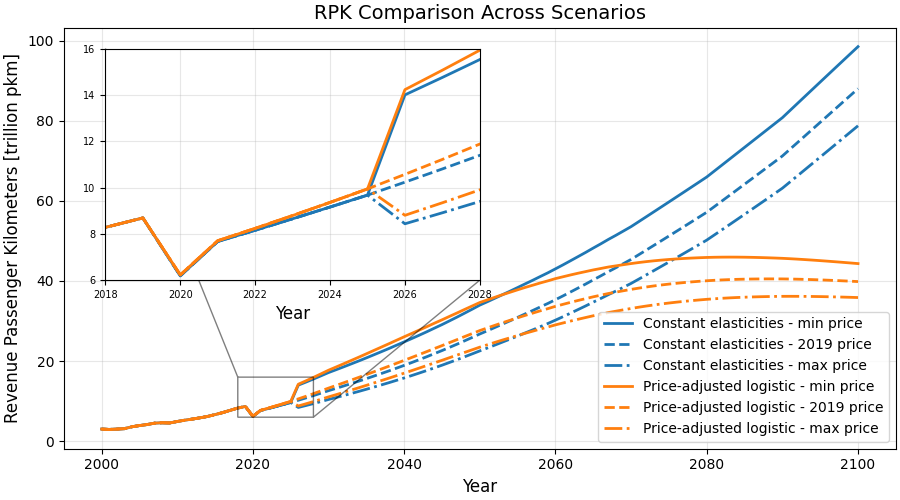

In [4]:
plot_instance = assembly.plot(
    "rpk_comparison", 
    scenario_groups={
        "Constant elasticities": [name for name in processes.keys() if "Constant elasticities" in name],
        "Price-adjusted logistic": [name for name in processes.keys() if "Price-adjusted logistic" in name],
    },
    legend="lower right",
)

ax_inset = plot_instance.ax.inset_axes([0.05, 0.4, 0.45, 0.55])
assembly.plot(
    "rpk_comparison",
    scenario_groups={
        "Constant elasticities": [name for name in processes.keys() if "Constant elasticities" in name],
        "Price-adjusted logistic": [name for name in processes.keys() if "Price-adjusted logistic" in name],
    },
    fig=plot_instance.fig,
    ax=ax_inset,
    legend=False,
)

ax_inset.set_xlim(2018, 2028)
ax_inset.set_ylim(6, 16)
ax_inset.set_ylabel("")
ax_inset.set_title("")
ax_inset.tick_params(labelsize=7)
plot_instance.ax.indicate_inset_zoom(ax_inset, edgecolor="black")
plot_instance.fig.savefig("model_comparison.pdf")

In [5]:
from aeromaps.utils.functions import clean_notebooks_on_tests

clean_notebooks_on_tests(globals())